# **1. Load CSV data**

In [5]:
import pandas as pd

# Loads the dataset from the URL using Pandas.
deaths_df = pd.read_csv('/content/time_series_covid19_deaths_global.csv')

# Displays the first few rows of the dataset to get an overview of its structure.
deaths_df.head()


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1933,1933,1933,1933,1933,1933,1933,1933,1933,1933


**a) Identify and handle missing values in the dataset.**

In [7]:
# 'isnull()' will return True where the data is missing, and 'sum()' counts the number of missing values per column.
missing_values = deaths_df.isnull().sum()

# Print the count of missing values for each column.
print("Missing values in each column:\n", missing_values)

# If we find any missing values, we can either drop the rows or fill them.
deaths_df_cleaned = deaths_df.dropna()

# Verify if missing values have been handled
print("Missing values after cleaning:\n", deaths_df_cleaned.isnull().sum())


Missing values in each column:
 Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
3/5/23              0
3/6/23              0
3/7/23              0
3/8/23              0
3/9/23              0
Length: 1147, dtype: int64
Missing values after cleaning:
 Province/State    0
Country/Region    0
Lat               0
Long              0
1/22/20           0
                 ..
3/5/23            0
3/6/23            0
3/7/23            0
3/8/23            0
3/9/23            0
Length: 1147, dtype: int64


**b) Remove duplicate entries if any.**

In [8]:
# 'duplicated()' will return True for duplicate rows, and 'sum()' counts them.
duplicate_rows = deaths_df_cleaned.duplicated().sum()

# Prints the number of duplicate rows.
print("Number of duplicate rows:", duplicate_rows)

# If there are duplicate rows, remove them using 'drop_duplicates()'.
deaths_df_cleaned = deaths_df_cleaned.drop_duplicates()

# Verifys if duplicates have been removed by checking for duplicates again.
print("Duplicate rows after cleaning:", deaths_df_cleaned.duplicated().sum())


Number of duplicate rows: 0
Duplicate rows after cleaning: 0


**c) Convert the date column to a consistent date format (e.g., YYYYMM-DD)**

In [9]:
# First, I gathered the columns that contain the date information.
date_columns = deaths_df_cleaned.columns[4:]  # Dates start from the 5th column onwards.

# We'll 'melt' the dataframe to convert date columns into rows, so we have a proper date column.
deaths_df_melted = deaths_df_cleaned.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
                                          var_name='Date', value_name='Deaths')

# Convert the 'Date' column to datetime format to standardize it.
deaths_df_melted['Date'] = pd.to_datetime(deaths_df_melted['Date'], format='%m/%d/%y')

# Display the cleaned dataset to verify the changes.
deaths_df_melted.head()


,Province/State,Country/Region,Lat,Long,Date,Deaths
0,Australian Capital Territory,Australia,-35.4735,149.0124,2020-01-22,0
1,New South Wales,Australia,-33.8688,151.2093,2020-01-22,0
2,Northern Territory,Australia,-12.4634,130.8456,2020-01-22,0
3,Queensland,Australia,-27.4698,153.0251,2020-01-22,0
4,South Australia,Australia,-34.9285,138.6007,2020-01-22,0


**d) Save the cleaned dataset to a new CSV file.**

In [10]:
# This will save the dataframe to a file named 'cleaned_covid19_deaths.csv'.
deaths_df_melted.to_csv('cleaned_covid19_deaths.csv', index=False)

# Print confirmation that the file has been saved.
print("Cleaned dataset has been saved as 'cleaned_covid19_deaths.csv'.")


Cleaned dataset has been saved as 'cleaned_covid19_deaths.csv'.


# **2. Display first 5 rows of the loaded data and do a short summary about the data**


In [11]:
print("First 5 rows of the cleaned dataset:")
print(deaths_df_melted.head())

# This dataset represents the number of deaths due to COVID-19, as recorded worldwide.
# The significant columns for geographic data are "Province/State," "Country/Region," "Lat," and "Long.".
# The "Deaths" column also has the accumulated total of deaths and the "Date" column reflects the reporting day.
# Dates are in standard format, with no missing or duplicate values.


First 5 rows of the cleaned dataset:
                 Province/State Country/Region      Lat      Long       Date  \
0  Australian Capital Territory      Australia -35.4735  149.0124 2020-01-22   
1               New South Wales      Australia -33.8688  151.2093 2020-01-22   
2            Northern Territory      Australia -12.4634  130.8456 2020-01-22   
3                    Queensland      Australia -27.4698  153.0251 2020-01-22   
4               South Australia      Australia -34.9285  138.6007 2020-01-22   

   Deaths  
0       0  
1       0  
2       0  
3       0  
4       0  


# **3. Calculate the mean and median of the daily cases.**

In [12]:
# Since the 'Deaths' column contains cumulative numbers, we need to calculate the daily death cases first.
# To do this, we'll group the data by 'Country/Region' and 'Date' to get the daily deaths for each country.

# Sort by date to make sure we calculate daily changes correctly.
deaths_df_melted = deaths_df_melted.sort_values(by=['Country/Region', 'Date'])

# Group by 'Country/Region' and 'Date', then calculate the daily increase in deaths.
deaths_df_melted['Daily_Deaths'] = deaths_df_melted.groupby(['Country/Region'])['Deaths'].diff().fillna(0)

# Calculate the mean and median of the daily death cases across all countries.
mean_daily_deaths = deaths_df_melted['Daily_Deaths'].mean()
median_daily_deaths = deaths_df_melted['Daily_Deaths'].median()

# Display the mean and median values.
print(f"Mean daily death cases: {mean_daily_deaths}")
print(f"Median daily death cases: {median_daily_deaths}")


Mean daily death cases: 0.011226124824284605
Median daily death cases: 0.0


# **4. Get Daily Death Cases Worldwide**

In [13]:
# Sum the 'Daily_Deaths' across all countries for each date.
worldwide_daily_deaths = deaths_df_melted.groupby('Date')['Daily_Deaths'].sum().reset_index()

# Display the first few rows of the worldwide daily deaths data.
print("Worldwide daily death cases (first 5 days):")
print(worldwide_daily_deaths.head())


Worldwide daily death cases (first 5 days):
        Date  Daily_Deaths
0 2020-01-22           0.0
1 2020-01-23           0.0
2 2020-01-24           0.0
3 2020-01-25           0.0
4 2020-01-26           0.0


# **5. Get Daily Increment in Deaths**

In [14]:
def calculate_daily_increase(df):
    # 'diff()' calculates the difference between successive rows in the 'Daily_Deaths' column.
    df['Daily_Increase'] = df['Daily_Deaths'].diff().fillna(0)
    return df

# Apply the function to the worldwide daily deaths data.
worldwide_daily_deaths = calculate_daily_increase(worldwide_daily_deaths)

# Display the first few rows to verify the calculations.
print("Worldwide daily death increment (first 5 days):")
print(worldwide_daily_deaths.head())


Worldwide daily death increment (first 5 days):
        Date  Daily_Deaths  Daily_Increase
0 2020-01-22           0.0             0.0
1 2020-01-23           0.0             0.0
2 2020-01-24           0.0             0.0
3 2020-01-25           0.0             0.0
4 2020-01-26           0.0             0.0


# **6. Visualize the Data with Matplotlib**

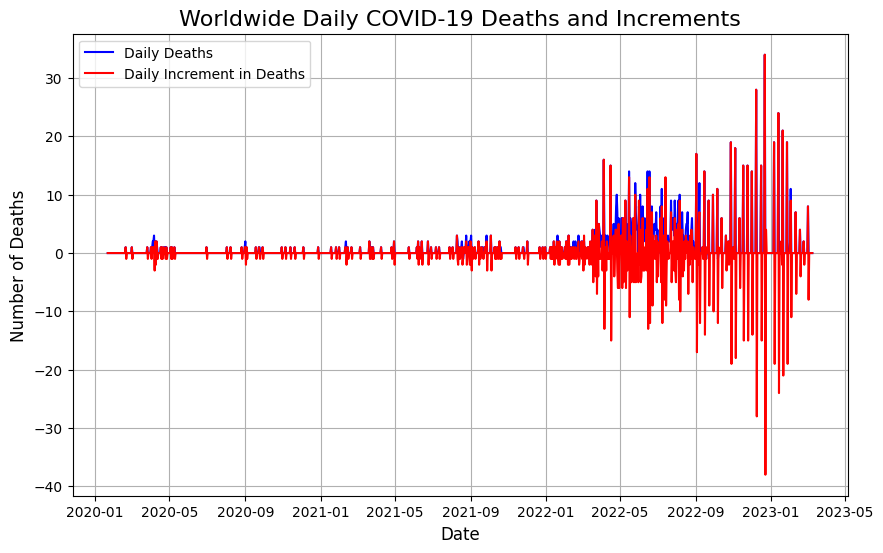

In [15]:
import matplotlib.pyplot as plt
# Plot the worldwide daily death cases.
plt.figure(figsize=(10, 6))

# Line plot for daily deaths.
plt.plot(worldwide_daily_deaths['Date'], worldwide_daily_deaths['Daily_Deaths'], label='Daily Deaths', color='blue')

# Line plot for daily death increment.
plt.plot(worldwide_daily_deaths['Date'], worldwide_daily_deaths['Daily_Increase'], label='Daily Increment in Deaths', color='red')

# Add titles and labels to the plot.
plt.title('Worldwide Daily COVID-19 Deaths and Increments', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.legend()

# Display the plot.
plt.grid(True)
plt.show()
